In [ ]:
#Tasks
    #1 Download train.csv from the Kaggle Titanic competition

    #2 Inspect the data: shape, types, missing values

    #3 Analyze survival rates by gender, class, and age group

    #4 Create bar plots and histograms using Matplotlib or Seaborn

    #5 Use relative frequencies when comparing distributions between survivors and non-survivors

    #6 Write short observations below each chart

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
#1
url = '../4. Titanic-Data/train.csv'

df = pd.read_csv(url)
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [45]:
#2 Inspect the data: shape, types, missing values
print (f"\nColumns Types: \n{df.dtypes}")
print (f"\nShape: \n{df.shape}\n")
for columns1 in df.columns:
    miss_values = df[columns1].isnull().sum()
    print(f"Missing Values for '{columns1}':{miss_values}")




Columns Types: 
PassengerId       int64
Survived          int64
Pclass            int64
Name             object
Sex              object
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Cabin            object
Embarked         object
Age_grouped    category
dtype: object

Shape: 
(891, 13)

Missing Values for 'PassengerId':0
Missing Values for 'Survived':0
Missing Values for 'Pclass':0
Missing Values for 'Name':0
Missing Values for 'Sex':0
Missing Values for 'Age':177
Missing Values for 'SibSp':0
Missing Values for 'Parch':0
Missing Values for 'Ticket':0
Missing Values for 'Fare':0
Missing Values for 'Cabin':687
Missing Values for 'Embarked':2
Missing Values for 'Age_grouped':177


In [49]:
#3 Analyze survival rates by gender, class, and age group
bins = [-1, 15, 21, 40, 60, 100]
labels = ["child-adolescent", "young adult", "adult", "old adult", "elderly"]

df["Age_grouped"] = pd.cut(df["Age"], bins=bins, labels=labels)
survival_gender = df.groupby("Sex")["Survived"].mean()
survival_class = df.groupby("Pclass")["Survived"].mean()
survival_age = df.groupby("Age_grouped")["Survived"].mean()

print (f"Survival Rates by gender: {survival_gender};\nSurvival Rates by class: {survival_class}; \nSurvival Rates by age: {survival_age}")

Survival Rates by gender: Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64;
Survival Rates by class: Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64; 
Survival Rates by age: Age_grouped
child-adolescent    0.590361
young adult         0.314050
adult               0.411111
old adult           0.390625
elderly             0.227273
Name: Survived, dtype: float64


/tmp/ipykernel_208/1995977148.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_age = df.groupby("Age_grouped")["Survived"].mean()


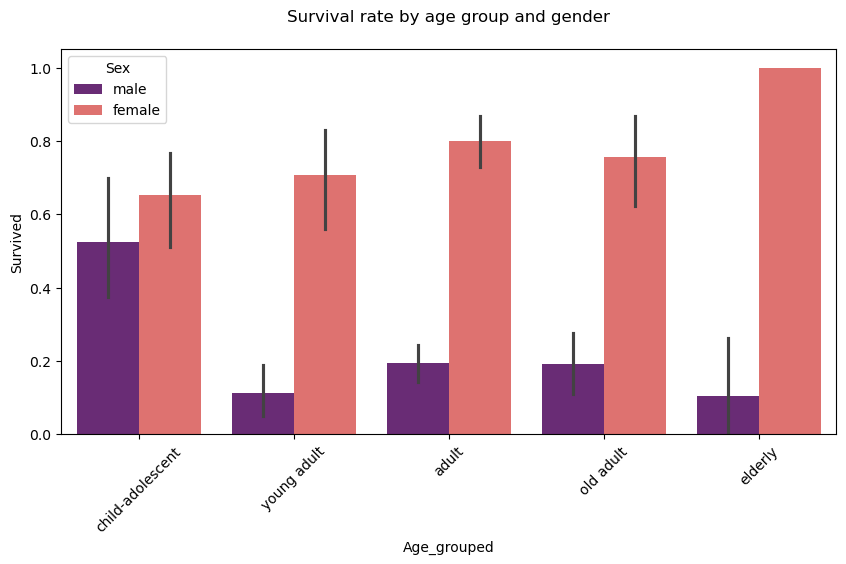

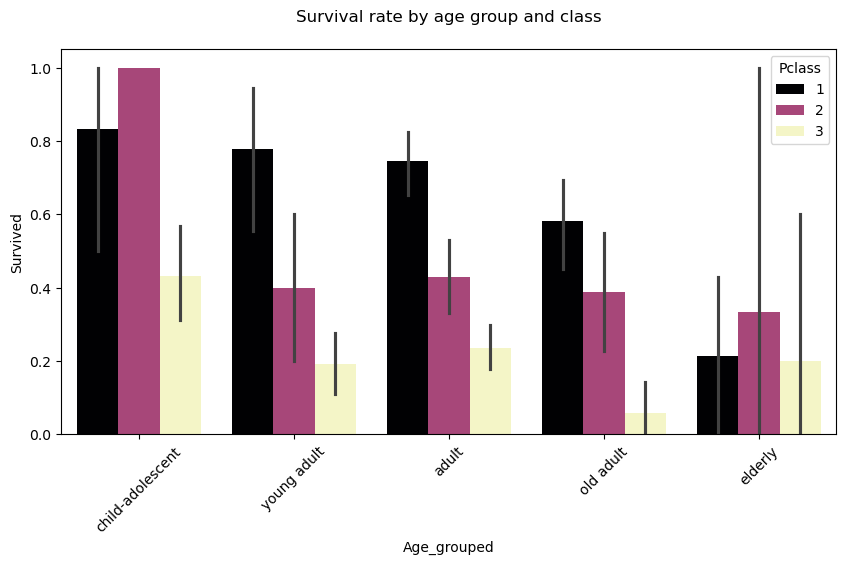

In [57]:
#4 Create bar plots and histograms using Matplotlib or Seaborn
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x="Age_grouped", y="Survived", hue="Sex", palette="magma")
plt.title("Survival rate by age group and gender", pad=20)
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=df, x="Age_grouped", y="Survived", hue="Pclass", palette="magma")
plt.title("Survival rate by age group and class", pad=20)
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='Age', ylabel='Density'>

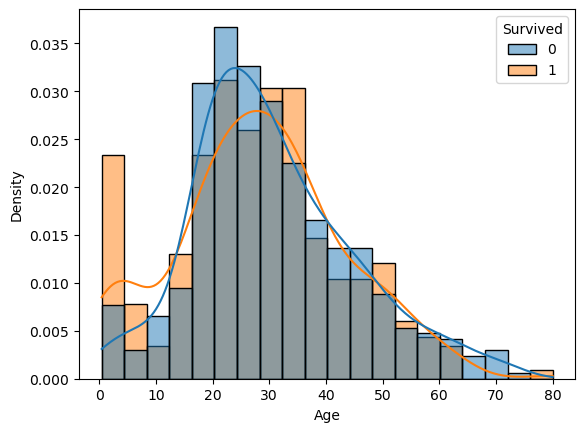

In [59]:
#5 Use relative frequencies when comparing distributions between survivors and non-survivors
sns.histplot(
    data=df,
    x="Age",
    hue="Survived",
    stat="density", 
    common_norm=False,
    kde=True,
)

In [ ]:
# High child survival rate: Note the very pronounced peak in the initial bar (infants and children aged 0–5, in orange),
#which significantly exceeds the distribution of those who did not survive (blue). This confirms the "women and children first" 
#rule applied during the rescue.

#Inverse proportion among young adults: In the 20–30 age range (the main peak of the blue non-survivor curve), 
#the density of those who lost their lives is proportionally higher compared to those who were saved.

#Similar behavior among older adults: From age 40 onwards, the densities of both curves cross and behave very similarly, 
#indicating that advanced age did not offer a drastic differential advantage or 
#disadvantage beyond the general trend observed among adults. 